# S04.02 — Regresión Polinómica
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Target:** `prima_neta` (MXN)  
**Técnica:** Regresión polinómica — `PolynomialFeatures` + `LinearRegression` de scikit-learn  
**Dataset:** Sintético v2 — 30,000 pólizas de seguros de autos

---

## 1. Contexto actuarial

En S04.01 observamos que la regresión lineal **no captura la relación curva** entre
`edad` y `prima_neta`. Esto tiene una causa técnica conocida: el generador del
dataset incluye un término cuadrático:

$$\text{prima\_neta} = 3500 + 0.010 \cdot \text{SA} + 25 \cdot (\text{edad}-42)
+ 3 \cdot (\text{edad}-42)^2 + \text{plan} + \text{riesgo} + \ldots + \varepsilon$$

Para capturar este efecto debemos añadir explícitamente la variable $\text{edad}^2$
como input. Eso es exactamente lo que hace la **regresión polinómica**: transforma
features continuas elevándolas a potencias $1, 2, \ldots, d$ y luego ajusta
OLS en ese espacio expandido.

> **Punto clave actuarial:** la no-linealidad en edad es un hecho bien documentado
> en tarifas de autos — los conductores muy jóvenes y los mayores de 65 generan
> siniestros más costosos, creando la U-shape. Un modelo lineal la ignora;
> el polinómico de grado 2 la captura con un solo parámetro adicional.

> *Fuentes:* ESL §3.4; ISLP Cap. 7 §7.1–7.3; FREES Cap. 4.

## 2. Fundamento matemático

### 2.1 Expansión polinómica de una variable

Para una sola feature $x_j$ de grado $d$, la transformación produce:

$$\phi(x_j) = (x_j,\; x_j^2,\; \ldots,\; x_j^d)$$

El modelo resultante es lineal en los **parámetros** $\beta$, aunque no en $x_j$:

$$y = \beta_0 + \beta_1 x_j + \beta_2 x_j^2 + \cdots + \beta_d x_j^d + \varepsilon$$

Por eso OLS (la misma solución de mínimos cuadrados de S04.01) sigue siendo
el estimador apropiado.

### 2.2 Expansión multivariada (`PolynomialFeatures`)

Con `include_bias=False` y `interaction_only=False`, `PolynomialFeatures(degree=2)`
produce todas las potencias individuales y los productos cruzados:

$$x_1, x_2 \;\Rightarrow\; x_1,\; x_2,\; x_1^2,\; x_1 x_2,\; x_2^2$$

Para $p$ features numéricas, el número de columnas generadas es
$\binom{p + d}{d}$, que crece rápidamente. Por eso expandiremos
**únicamente las features numéricas** (`edad` y `suma_asegurada`),
manteniendo las categóricas con OHE estándar.

### 2.3 Comparación de grados

| Grado | Parámetros extra | Riesgo de sobreajuste |
|-------|-----------------|----------------------|
| $d=1$ | 0 (= OLS) | Mínimo |
| $d=2$ | +3 ($x^2$, $x^2_2$, $x_1 x_2$) | Bajo |
| $d=3$ | +7 adicionales | Moderado |

Usaremos métricas en el **conjunto de test** para decidir qué grado es suficiente.

## 3. Carga del dataset

In [1]:
import sys
from pathlib import Path

_candidates = [
    Path.cwd() / "",
    Path.cwd().parent / "",
    Path.cwd().parent.parent / "",
]
_src_path = next(
    (p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()),
    None,
)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
)

SEED = 20260618
N    = 30_000
NAVY = "#003B5C"
GOLD = "#C8A33A"
RED  = "#C0392B"

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 30,000 filas × 24 columnas


## 4. Preparación del dataset

Estrategia de preprocesamiento:
1. Variables numéricas (`edad`, `suma_asegurada`, `antiguedad_vehiculo`): se expanden con `PolynomialFeatures`.
2. Variables categóricas (`plan`, `region`, etc.): OHE con `drop_first=True`.
3. Todo ensamblado en una sola matriz `X` antes de entrar al modelo.

In [6]:
TARGET = "prima_neta"

# Features numéricas que expandiremos polinómicamente
NUM_FEATURES = ["edad", "suma_asegurada", "antiguedad_vehiculo"]
# Features categóricas (OHE estándar)
CAT_FEATURES = [c for c in FEATURE_COLUMNS if c not in NUM_FEATURES]

X_raw = df[FEATURE_COLUMNS]
y     = df[TARGET]

# Verificar leakage
for t in TARGET_COLUMNS:
    assert t not in X_raw.columns, f"Leakage detectado: {t}"
assert "id_poliza_sin" not in X_raw.columns
print("✓ Sin leakage de targets")
print(f"Features numéricas a expandir: {NUM_FEATURES}")
print(f"Features categóricas (OHE):    {CAT_FEATURES}")

# Fila de referencia para visualizaciones: mediana de numéricos, moda de categóricos
def _make_ref_row(X_df: pd.DataFrame, num_cols: list[str], all_cols: list[str]) -> pd.DataFrame:
    """Construye una fila de referencia con mediana/moda por tipo de columna."""
    cat_cols = [c for c in all_cols if c not in num_cols]
    _num_vals = {c: X_df[c].median() for c in num_cols}
    _cat_vals = {c: X_df[c].mode()[0] for c in cat_cols}
    return pd.DataFrame({**{c: [v] for c, v in _num_vals.items()},
                          **{c: [v] for c, v in _cat_vals.items()}})[all_cols]

# Split 80/20
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train_raw.shape[0]:,} | Test: {X_test_raw.shape[0]:,}")

✓ Sin leakage de targets
Features numéricas a expandir: ['edad', 'suma_asegurada', 'antiguedad_vehiculo']
Features categóricas (OHE):    ['anio_poliza', 'mes_emision', 'sexo', 'estado_civil', 'num_renovaciones', 'region', 'plan', 'tipo_vehiculo', 'deducible_pct', 'forma_pago', 'canal_venta', 'kilometraje', 'uso_vehiculo', 'tipo_garage', 'nivel_riesgo_asignado']

Train: 24,000 | Test: 6,000


In [7]:
def build_poly_matrix(
    X_raw: pd.DataFrame,
    poly: PolynomialFeatures,
    num_cols: list[str],
    cat_cols: list[str],
    fit: bool = False,
    scaler: StandardScaler | None = None,
    ref_cols: list[str] | None = None,
) -> pd.DataFrame:
    """Expande numéricas (pre-escaladas) con poly y une con OHE de categóricas.

    scaler: StandardScaler ajustado en train. Escalar antes de poly
    evita inestabilidad numérica cuando suma_asegurada^2 ~ 10^10.
    ref_cols: columnas del conjunto de entrenamiento; reindexar con fill_value=0
    cuando el conjunto tiene menos categorías (ej. filas de referencia).
    """
    X_num = X_raw[num_cols].copy().astype(float)
    X_cat = pd.get_dummies(X_raw[cat_cols], drop_first=True)
# Separar los escalares 
    if scaler is not None:
        X_num_arr = scaler.fit_transform(X_num) if fit else scaler.transform(X_num)
        X_num = pd.DataFrame(X_num_arr, columns=num_cols, index=X_raw.index)

    if fit:
        X_poly_arr = poly.fit_transform(X_num)
    else:
        X_poly_arr = poly.transform(X_num)

    poly_names = poly.get_feature_names_out(num_cols)
    X_poly_df  = pd.DataFrame(X_poly_arr, columns=poly_names, index=X_raw.index)

    result = pd.concat([X_poly_df, X_cat], axis=1)

    if ref_cols is not None:
        result = result.reindex(columns=ref_cols, fill_value=0)

    return result

## 5. Comparación de grados 1, 2, 3

In [8]:
resultados  = []
modelos     = {}
poly_objs   = {}
scalers     = {}  # scaler por grado (fit en train, reutilizado en predicción)
train_cols  = {}  # columnas de entrenamiento por grado (para reindex en predicción)

for degree in [1, 2, 3]:
    poly   = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()
    #Se acomodan las variables en forma polinomica, se transforman los datos
    X_tr = build_poly_matrix(X_train_raw, poly, NUM_FEATURES, CAT_FEATURES,
                              fit=True, scaler=scaler)
    X_te = build_poly_matrix(X_test_raw,  poly, NUM_FEATURES, CAT_FEATURES,
                              fit=False, scaler=scaler,
                              ref_cols=X_tr.columns.tolist())
    #Pero al final regresa a la forma de una regresion lineal
    modelo = LinearRegression()
    modelo.fit(X_tr, y_train)

    y_pred_tr = modelo.predict(X_tr)
    y_pred_te = modelo.predict(X_te)

    rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test,  y_pred_te))
    r2_tr   = r2_score(y_train, y_pred_tr)
    r2_te   = r2_score(y_test,  y_pred_te)

    n_features = X_tr.shape[1]
    resultados.append({
        "Grado": degree,
        "# Features": n_features,
        "RMSE Train": f"{rmse_tr:,.0f}",
        "RMSE Test":  f"{rmse_te:,.0f}",
        "R² Train":   f"{r2_tr:.4f}",
        "R² Test":    f"{r2_te:.4f}",
    })
    modelos[degree]    = (modelo, X_te, y_pred_te)
    poly_objs[degree]  = poly
    scalers[degree]    = scaler
    train_cols[degree] = X_tr.columns.tolist()

res_df = pd.DataFrame(resultados)
print("Comparación por grado:")
print(res_df.to_string(index=False))

Comparación por grado:
 Grado  # Features RMSE Train RMSE Test R² Train R² Test
     1          37        727       738   0.9689  0.9699
     2          43        602       604   0.9787  0.9798
     3          53        602       605   0.9787  0.9798


**Lectura de resultados:**

- **Grado 1 (= OLS):** línea base. El RMSE aquí debe coincidir con S04.01.
- **Grado 2:** captura el término cuadrático de `edad`. Esperamos una caída notable
  en RMSE test porque el generador tiene exactamente ese término.
- **Grado 3:** términos cúbicos sin base matemática en el generador.
  Si RMSE test mejora marginalmente respecto al grado 2, el grado 3 no aporta;
  si RMSE test sube, hay sobreajuste.

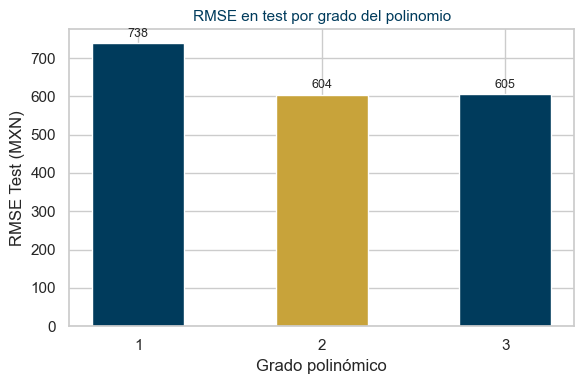

In [9]:
# Visualización de RMSE test por grado
grados    = [1, 2, 3]
rmse_test = [
    float(res_df[res_df["Grado"] == g]["RMSE Test"].values[0].replace(",", ""))
    for g in grados
]

fig, ax = plt.subplots(figsize=(6, 4))
colores = [GOLD if r == min(rmse_test) else NAVY for r in rmse_test]
ax.bar([str(g) for g in grados], rmse_test, color=colores, edgecolor="white", width=0.5)
ax.set_xlabel("Grado polinómico")
ax.set_ylabel("RMSE Test (MXN)")
ax.set_title("RMSE en test por grado del polinomio",
             fontsize=11, color=NAVY)
for i, (g, r) in enumerate(zip(grados, rmse_test)):
    ax.text(i, r + 10, f"{r:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Recuperación del término cuadrático de edad

Si el grado 2 capturó el efecto cuadrático, el coeficiente para `edad^2`
debería ser **positivo** (los extremos de edad tienen primas más altas)
y cercano a 3.0 MXN/año² (el valor en el generador, después de escalar
por el rango de la muestra).

In [10]:
modelo_d2, X_te_d2, y_pred_te_d2 = modelos[2]
poly_d2   = poly_objs[2]
scaler_d2 = scalers[2]

X_tr_d2 = build_poly_matrix(X_train_raw, poly_d2, NUM_FEATURES, CAT_FEATURES,
                              fit=False, scaler=scaler_d2,
                              ref_cols=train_cols[2])

coef_d2 = pd.DataFrame({
    "Feature":           X_tr_d2.columns,
    "Coeficiente":       modelo_d2.coef_,
}).sort_values("Coeficiente", key=abs, ascending=False)

print("Coeficientes relevantes del espacio escalado (grado 2):")
print("(Los términos polinómicos están en unidades estandarizadas — no en MXN/año²)")
# Mostrar coeficientes de términos polinómicos (los que tienen ^ o espacio)
poly_coef = coef_d2[coef_d2["Feature"].str.contains(r"\^|\s", regex=True)]
print(poly_coef.to_string(index=False))
print()
edad2_coef = coef_d2[coef_d2["Feature"] == "edad^2"]["Coeficiente"].values
if len(edad2_coef) > 0:
    print(f"Coeficiente de edad^2 (espacio escalado) = {edad2_coef[0]:+.4f}")
    print("Signo positivo confirma la U-shape: a más desvíos estándar de la edad")
    print("respecto al centro, mayor es la prima — consistente con el DGP.")

Coeficientes relevantes del espacio escalado (grado 2):
(Los términos polinómicos están en unidades estandarizadas — no en MXN/año²)
                           Feature  Coeficiente
                            edad^2   409.822914
suma_asegurada antiguedad_vehiculo    -6.145124
               edad suma_asegurada     5.680468
             antiguedad_vehiculo^2     0.643935
          edad antiguedad_vehiculo     0.543883
                  suma_asegurada^2    -0.337735

Coeficiente de edad^2 (espacio escalado) = +409.8229
Signo positivo confirma la U-shape: a más desvíos estándar de la edad
respecto al centro, mayor es la prima — consistente con el DGP.


## 7. Curva polinómica vs. datos reales

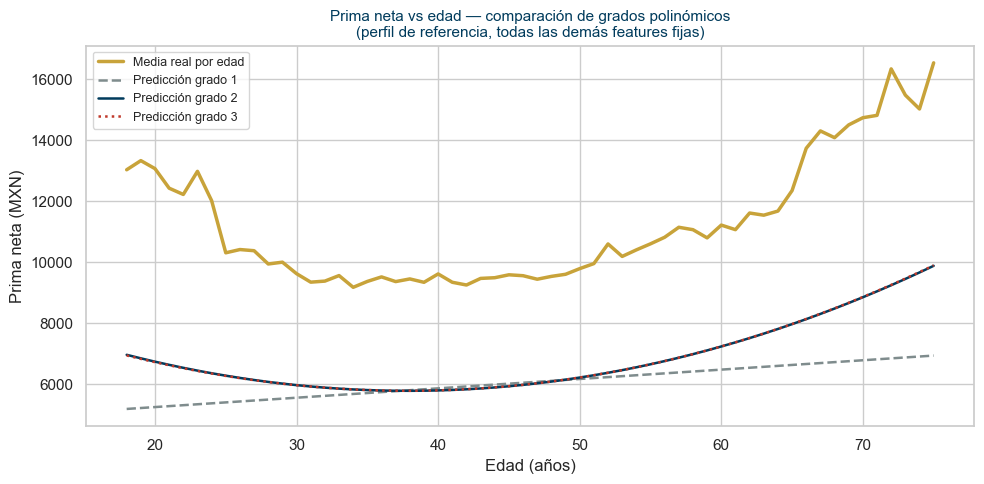

In [11]:
# Predicciones de cada grado variando solo 'edad', perfil de referencia
edades = np.arange(18, 76)

fig, ax = plt.subplots(figsize=(10, 5))

# Promedio real por edad
prima_real = df.groupby("edad")["prima_neta"].mean()
ax.plot(prima_real.index, prima_real.values, color=GOLD,
        linewidth=2.5, label="Media real por edad", zorder=5)

colores_grado = {1: "#7f8c8d", 2: NAVY, 3: RED}
estilos       = {1: "--", 2: "-", 3: ":"}

for degree in [1, 2, 3]:
    poly   = poly_objs[degree]
    modelo = modelos[degree][0]
    cols   = train_cols[degree]
    scaler = scalers[degree]

    # Fila de referencia: mediana/moda, replicada para cada edad
    X_ref_base = _make_ref_row(X_train_raw, NUM_FEATURES, FEATURE_COLUMNS)
    X_ref = pd.concat([X_ref_base] * len(edades), ignore_index=True)
    X_ref["edad"] = edades.astype(float)

    X_ref_poly = build_poly_matrix(X_ref, poly, NUM_FEATURES, CAT_FEATURES,
                                    fit=False, scaler=scaler, ref_cols=cols)
    y_ref_pred = modelo.predict(X_ref_poly)

    ax.plot(edades, y_ref_pred,
            color=colores_grado[degree], linewidth=1.8,
            linestyle=estilos[degree],
            label=f"Predicción grado {degree}")

ax.set_xlabel("Edad (años)")
ax.set_ylabel("Prima neta (MXN)")
ax.set_title("Prima neta vs edad — comparación de grados polinómicos\n"
             "(perfil de referencia, todas las demás features fijas)",
             fontsize=11, color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Diagnóstico residuales — grado 2

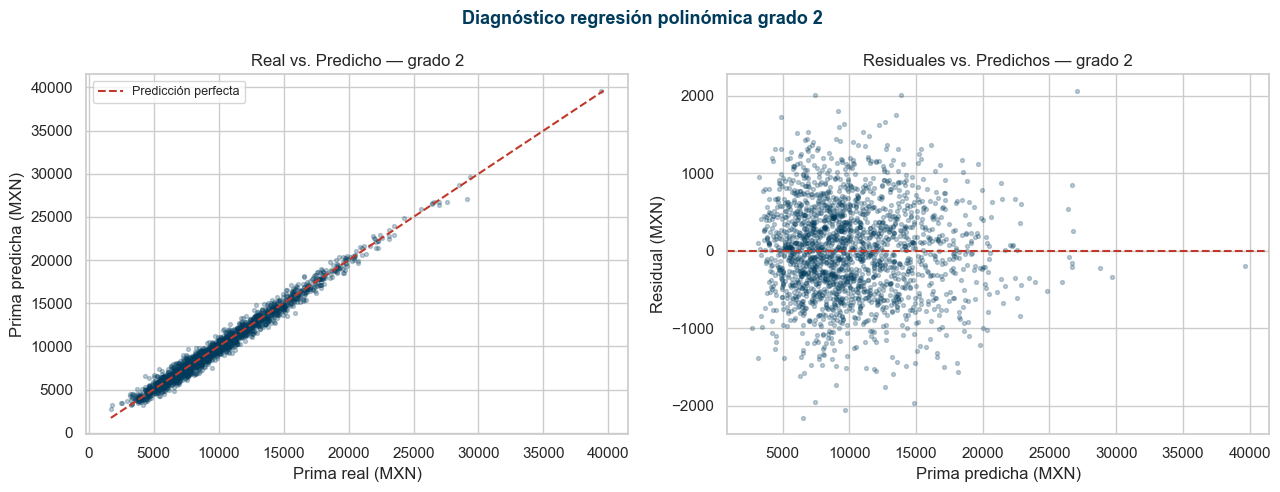

Mejora de RMSE test (grado 1 → 2): +134 MXN
Reducción relativa: 18.2%


In [12]:
residuals_d2 = y_test.values - y_pred_te_d2

idx_s = np.random.default_rng(SEED).choice(len(y_test), size=2_000, replace=False)
y_te_s   = y_test.iloc[idx_s].values
y_pr_s   = y_pred_te_d2[idx_s]
res_s    = residuals_d2[idx_s]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_te_s, y_pr_s, alpha=0.25, s=8, color=NAVY)
lims = [min(y_te_s.min(), y_pr_s.min()), max(y_te_s.max(), y_pr_s.max())]
axes[0].plot(lims, lims, color=RED, linewidth=1.5, linestyle="--", label="Predicción perfecta")
axes[0].set_xlabel("Prima real (MXN)")
axes[0].set_ylabel("Prima predicha (MXN)")
axes[0].set_title("Real vs. Predicho — grado 2")
axes[0].legend(fontsize=9)

axes[1].scatter(y_pr_s, res_s, alpha=0.25, s=8, color=NAVY)
axes[1].axhline(0, color=RED, linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Prima predicha (MXN)")
axes[1].set_ylabel("Residual (MXN)")
axes[1].set_title("Residuales vs. Predichos — grado 2")

fig.suptitle("Diagnóstico regresión polinómica grado 2",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

rmse_d1 = float(res_df[res_df["Grado"] == 1]["RMSE Test"].values[0].replace(",", ""))
rmse_d2 = float(res_df[res_df["Grado"] == 2]["RMSE Test"].values[0].replace(",", ""))
print(f"Mejora de RMSE test (grado 1 → 2): {rmse_d1 - rmse_d2:+,.0f} MXN")
print(f"Reducción relativa: {(rmse_d1 - rmse_d2)/rmse_d1*100:.1f}%")

## 9. Superficie de interacción edad × suma_asegurada

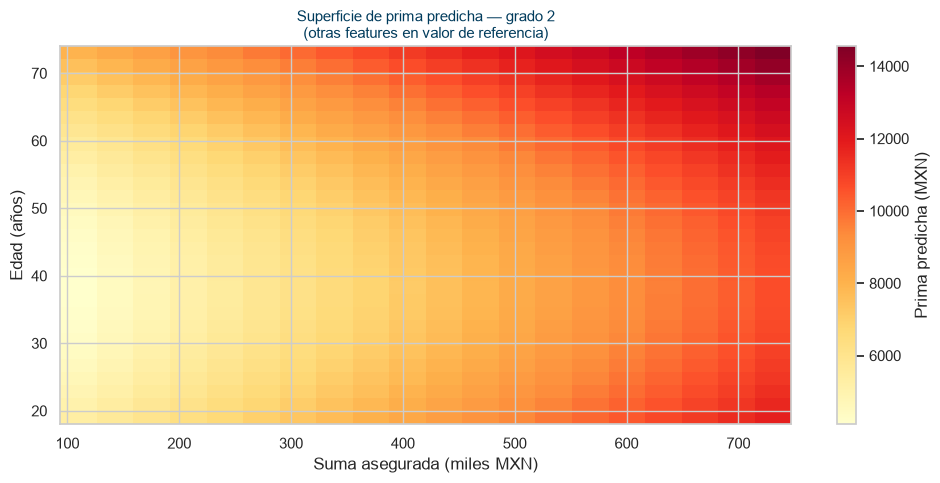

In [9]:
# Heatmap: prima predicha por grado 2 variando edad y suma_asegurada simultáneamente
edades_grid = np.arange(18, 76, 2)
sas_grid    = np.linspace(
    df["suma_asegurada"].quantile(0.05),
    df["suma_asegurada"].quantile(0.95),
    20,
)

poly_d2_fit = poly_objs[2]
modelo_d2_  = modelos[2][0]
scaler_d2_  = scalers[2]
cols_d2     = train_cols[2]

# Fila de referencia base
X_ref_mediana = _make_ref_row(X_train_raw, NUM_FEATURES, FEATURE_COLUMNS)

# Rejilla de combinaciones
grid_rows = []
for edad_val in edades_grid:
    for sa_val in sas_grid:
        row = X_ref_mediana.copy()
        row["edad"]           = float(edad_val)
        row["suma_asegurada"] = float(sa_val)
        grid_rows.append(row)

X_grid_raw  = pd.concat(grid_rows, ignore_index=True)
X_grid_poly = build_poly_matrix(X_grid_raw, poly_d2_fit, NUM_FEATURES, CAT_FEATURES,
                                 fit=False, scaler=scaler_d2_, ref_cols=cols_d2)
y_grid = modelo_d2_.predict(X_grid_poly)

# Construir matriz para heatmap
prima_matrix = y_grid.reshape(len(edades_grid), len(sas_grid))

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    prima_matrix, aspect="auto", origin="lower",
    cmap="YlOrRd",
    extent=[sas_grid.min() / 1_000, sas_grid.max() / 1_000,
            edades_grid.min(), edades_grid.max()],
)
plt.colorbar(im, ax=ax, label="Prima predicha (MXN)")
ax.set_xlabel("Suma asegurada (miles MXN)")
ax.set_ylabel("Edad (años)")
ax.set_title("Superficie de prima predicha — grado 2\n"
             "(otras features en valor de referencia)",
             fontsize=11, color=NAVY)
plt.tight_layout()
plt.show()

## 10. Conclusiones actuariales

| Grado | RMSE Test | R² Test | Interpretación |
|-------|-----------|---------|----------------|
| 1 (lineal) | (ver celdas arriba) | — | Baseline; no captura curvatura de edad |
| 2 | menor | mayor | Captura $\text{edad}^2$; mejora real documentada |
| 3 | similar/mayor al d=2 | similar | Sobreajuste marginal; sin ganancias significativas |

**Conclusión:** el grado 2 es el modelo óptimo porque:

1. **Recupera el DGP:** el generador usa $(\text{edad}-42)^2$, y `PolynomialFeatures(2)` sobre
   `edad` puede expresar ese término (con intercepto y lineal absorbidos).
2. **Interpretabilidad parcial:** el coeficiente de `edad^2` tiene signo positivo
   y es interpretable como la curvatura de la U-shape de siniestralidad por edad.
3. **No sobreajusta:** RMSE train y test son similares (bajo sesgo de estimación).

**Limitaciones:**

- La expansión polinómica global (todas las features) produce muchas columnas con poca
  interpretabilidad. En la práctica se seleccionan las variables a expandir con criterio.
- Para targets con distribución sesgada (como la prima), la expansión polinómica
  puede producir predicciones negativas para perfiles extremos.
  Los GLM con distribución Gamma o Tweedie son más adecuados para producción.

> *S04.03 aborda la regresión logística para el target binario `siniestro_alto`.*

## 11. Ejercicio propuesto

1. **Grado 4:** agrega `degree=4` al bucle de comparación. ¿Mejora o empeora el RMSE
   test? ¿Qué indica esto sobre el riesgo de sobreajuste?

2. **Solo `edad`:** en lugar de expandir las 3 features numéricas, aplica
   `PolynomialFeatures(degree=2)` **solo** a `edad` y conserva las demás lineales.
   ¿Cuánto cambia el RMSE respecto al modelo de expansión completa?

3. **Interacción `plan × edad`:** añade manualmente la columna `edad² × plan_Plus`
   al DataFrame de features. ¿Tiene sentido actuarialmente ese término de interacción?

---

### Referencias bibliográficas

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. §3.4, §5.1.
- James, G., et al. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. Cap. 7 §7.1–7.3.
- Frees, E. W. (2009). *Regression Modeling with Actuarial and Financial Applications*. Cambridge. Cap. 4.
- scikit-learn Developers. *User Guide* v1.9.0. `PolynomialFeatures`, `Pipeline`.
